<a href="https://colab.research.google.com/github/manuela1702/forestfires_filledgt/blob/main/forestfires_filledgt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import math
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/forestfires_filledgt.csv')

# Display first 5 rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.972242,11.922166
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.491960,46.074340
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.408359,49.051666
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.200000,68.903192
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.392471,33.988382


In [3]:
# Rename columns to more descriptive names
df_reg = df.rename(columns={
    "temp": "temperature",
    "RH": "humidity",
    "wind": "wind_speed",
    "rain": "rainfall",
    "area": "burned_area"
})

df_reg.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temperature,humidity,wind_speed,rainfall,burned_area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.972242,11.922166
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.491960,46.074340
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.408359,49.051666
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.200000,68.903192
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.392471,33.988382


In [4]:
# Display only the columns we will analyze
df_reg[["temperature", "humidity", "wind_speed", "rainfall", "burned_area"]].head()

,temperature,humidity,wind_speed,rainfall,burned_area
0,8.2,51,6.7,0.972242,11.922166
1,18.0,33,0.9,0.491960,46.074340
2,14.6,33,1.3,0.408359,49.051666
3,8.3,97,4.0,0.200000,68.903192
4,11.4,99,1.8,0.392471,33.988382


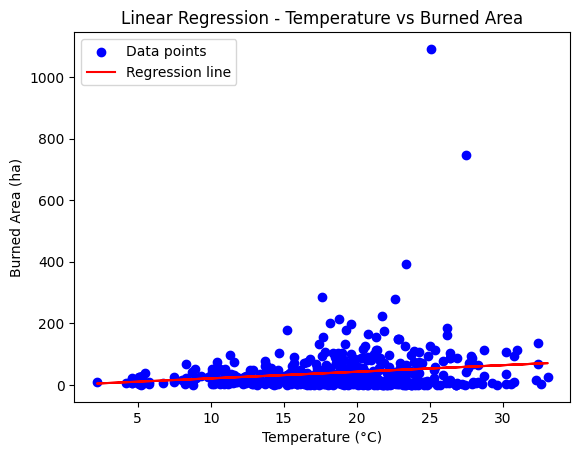

                            OLS Regression Results                            
Dep. Variable:            burned_area   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     14.52
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           0.000156
Time:                        20:11:40   Log-Likelihood:                -2835.7
No. Observations:                 498   AIC:                             5675.
Df Residuals:                     496   BIC:                             5684.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0330     10.988     -0.003      

In [5]:
# LINEAR REGRESSION
# Define dependent and independent variables
y = df_reg["burned_area"]      # dependent variable
x = df_reg["temperature"]      # independent variable

# Add intercept constant
M1 = sm.add_constant(x)

# Fit OLS model
model1 = sm.OLS(y, M1).fit()

# Predict burned area
y_pred1 = model1.predict(M1)

# Plot data points and regression line
plt.scatter(x, y, color="blue", label="Data points")
plt.plot(x, y_pred1, color="red", label="Regression line")
plt.title("Linear Regression - Temperature vs Burned Area")
plt.xlabel("Temperature (°C)")
plt.ylabel("Burned Area (ha)")
plt.legend()
plt.show()

# Display model summary
print(model1.summary())

Linear Regression - Temperature vs Burned Area

In this section, simple linear regression was applied to examine the relationship
between temperature and burned area, using the OLS method (Ordinary Least Squares).

The goal of the analysis was to determine whether an increase in temperature
leads to an increase in the burned area.

Based on the results, the model shows statistical significance and temperature
does have an influence, however it is not sufficient on its own to fully
explain the variation in burned area.